In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import probplot

In [10]:
df = pd.read_csv("data/mlb_stats.csv")

In [11]:
df.head()

,"last_name, first_name",player_id,year,player_age,pa,home_run,k_percent,bb_percent,batting_avg,on_base_plus_slg,...,avg_swing_speed,fast_swing_rate,launch_angle_avg,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_best_speed,whiff_percent,pull_percent,groundballs_percent
0,"Cabrera, Miguel",408234,2023,40,370,4,20.0,8.4,0.257,0.675,...,68.3,0.7,7.4,34.2,4.2,37.6,98.972071,25.6,35.7,49.8
1,"Peralta, David",444482,2023,35,422,7,17.1,4.7,0.259,0.675,...,72.1,24.5,8.2,31.1,4.9,44.2,100.838135,22.5,38.4,49.1
2,"Blackmon, Charlie",453568,2023,36,413,8,13.3,9.4,0.279,0.803,...,66.9,1.6,18.1,39.0,4.9,31.5,97.605452,19.6,45.5,36.4
3,"Maldonado, Martín",455117,2023,36,407,15,34.2,7.4,0.191,0.606,...,71.8,15.6,18.1,32.8,8.5,40.0,99.511384,34.3,46.0,38.7
4,"Solano, Donovan",456781,2023,35,450,5,22.2,8.9,0.282,0.760,...,68.2,6.3,13.1,43.1,6.1,43.7,100.102936,25.4,34.2,41.0


In [12]:
df.shape

(961, 22)

# Abstract

# Introduction

# Methodology

# Data

### Data Source

The data was sourced from [Baseball Savant](https://baseballsavant.mlb.com/), the official advanced statistics webpage for Major League Baseball. We used their Custom Leaderboard feature to make a custom dataset linked [here](https://baseballsavant.mlb.com/leaderboard/custom?year=2025%2C2024%2C2023&type=batter&filter=&min=250&selections=player_age%2Cpa%2Chome_run%2Ck_percent%2Cbb_percent%2Cbatting_avg%2Con_base_plus_slg%2Cb_gnd_into_dp%2Cwoba%2Cavg_swing_speed%2Cfast_swing_rate%2Claunch_angle_avg%2Csweet_spot_percent%2Cbarrel_batted_rate%2Chard_hit_percent%2Cavg_best_speed%2Cwhiff_percent%2Cpull_percent%2Cgroundballs_percent&chart=false&x=pa&y=pa&r=no&chartType=beeswarm&sort=pa&sortDir=desc). As a group we chose to include 22 total variables (columns). Each observation is a player's batting statistics within a season. We included observations from three different years (the 2023, 2024, and 2025 seasons).

#### Observations and Sample

There are 961 total observations (rows) in the dataset. Out of the total Baseball Savant database, we do not have a completely random sample of the data. However, in order to draw proper conclusions from each observation, we have to put nonrandom filters on the observations to control for as much random noise as possible. The main filters are the seasons we are using (2023-2025), and only players with a minimum of 250 plate appearances in a season are considered. We still include every possible data point matching the criteria we filter for. In totality, we have every MLB player's single season batting statistics from 2023 to 2025 who had at least 250 plate appearances. Since we are not leaving out any observations after filtering the data, we have a census of the population space described above. Our scope of inference is the entire population space since we are not leaving out any observations. For MLB players who have at least 250 plate appearances in a season, it's reasonable to assume that our findings can apply to hitter statistics in the present and near future.

### Missingness and Duplicates

Below, we check for missingness in the dataset by using the `missingno` library to construct a missingness bar plot. 

<Axes: >

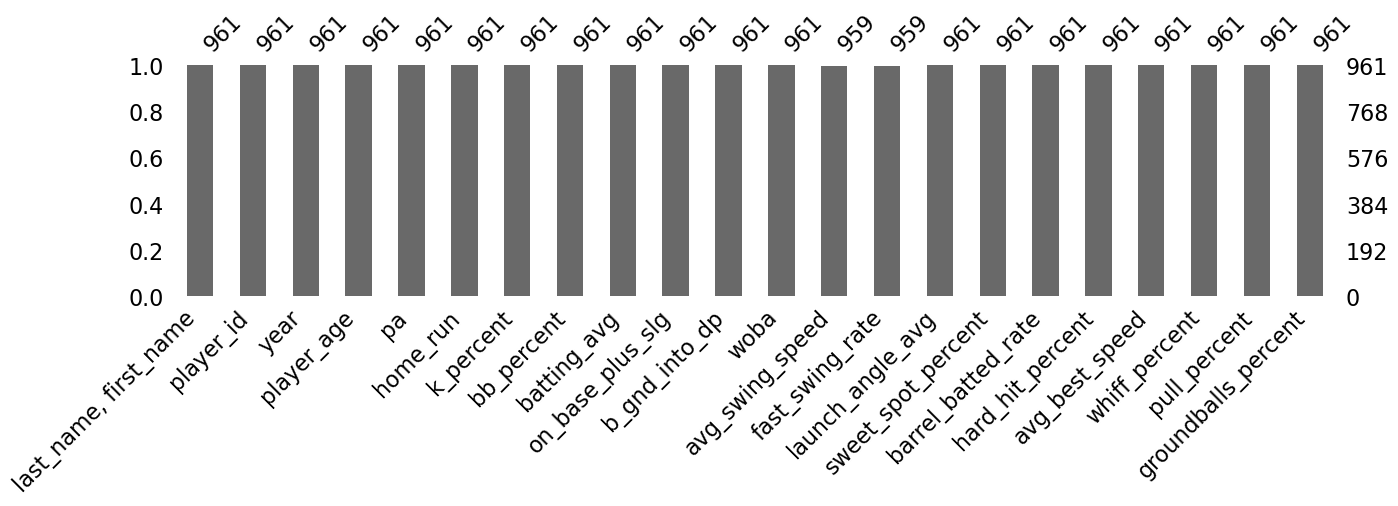

In [13]:
msno.bar(df, figsize = (15, 3))

We can see that there is a couple of values missing for `avg_swing_speed` and `fast_swing_rate`. Let's take a look at where these missing values appear in the dataset.

In [14]:
missing_rows = df[df.isna().any(axis = 1)]
missing_rows

,"last_name, first_name",player_id,year,player_age,pa,home_run,k_percent,bb_percent,batting_avg,on_base_plus_slg,...,avg_swing_speed,fast_swing_rate,launch_angle_avg,sweet_spot_percent,barrel_batted_rate,hard_hit_percent,avg_best_speed,whiff_percent,pull_percent,groundballs_percent
295,"Vargas, Miguel",678246,2023,23,304,7,20.1,12.5,0.195,0.672,...,NaN,NaN,16.6,32.0,6.0,31.5,97.543796,22.3,37.0,38.0
319,"Pasquantino, Vinnie",686469,2023,25,260,9,11.9,9.6,0.247,0.761,...,NaN,NaN,17.4,37.8,7.5,40.3,99.993888,17.4,40.8,36.8


Doing a little bit of research on these two players, it appears that both of these players only played games up until June and July of 2023. This is notable because bat tracking data was only publicly released in [May 2024](https://www.mlb.com/news/what-you-need-to-know-about-statcast-bat-tracking) for the 2024 season, and then retroactively they released bat tracking data on the latter half of the 2023 season. This means that both Miguel Vargas and Vinnie Pasquantino did not qualify under MLB's minimum requirement to track those statistics. This also raises a problem where the bat speed statistics from 2023 are from only the latter half of the season, though the sample size should be large enough that the stats are mostly stabilized.

Importantly, this means that the data is MAR (Missing At Random) since we know the reason why the data is missing in this dataset, it's just unlucky that these players had their seasons cut short. Miguel Vargas was optioned down to the minor leagues which may not be totally random, but Vinnie Pasquantino suffered a season ending injury, which can happen to anyone and is random. In this case, since we know the mechanism behind why the observations are missing (timing), and it's only 2 out of 691 observations, it's best to drop the two rows as they only account for $0.2\%$ of the total data and the bias introduced by dropping the two observations is negligible.

In [15]:
df = df.dropna()
df.shape

(959, 22)

We have removed the rows with missing observations and dealt with the missing data!

Additionally, we will check for duplicate values in the dataset.

In [16]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values in the dataset!

### Restructuring and Relabeling

Now let's check the names of the columns to see if we need to change them. Ideally we only want lowercase letters and underscores that act as spaces.

In [17]:
df.columns

Index(['last_name, first_name', 'player_id', 'year', 'player_age', 'pa',
       'home_run', 'k_percent', 'bb_percent', 'batting_avg',
       'on_base_plus_slg', 'b_gnd_into_dp', 'woba', 'avg_swing_speed',
       'fast_swing_rate', 'launch_angle_avg', 'sweet_spot_percent',
       'barrel_batted_rate', 'hard_hit_percent', 'avg_best_speed',
       'whiff_percent', 'pull_percent', 'groundballs_percent'],
      dtype='object')

Most of the column names appear to be tidied up which is great! The only column names that we should change are `last_name, first_name` and `on_base_plus_slg`. `last_name, first_name` contains a space and comma which we do not want. We will rename the column to `player_name`. `on_base_plus_slg` is an okay column name, but as the outcome variable it will be called constantly and the name is a tad long. Since we already know this variable under a different and much shorter name (OPS), we will convert the column name to `ops`.

In [18]:
df = df.rename(columns = {"last_name, first_name": "player_name",
                          "on_base_plus_slg": "ops"})
df.columns

Index(['player_name', 'player_id', 'year', 'player_age', 'pa', 'home_run',
       'k_percent', 'bb_percent', 'batting_avg', 'ops', 'b_gnd_into_dp',
       'woba', 'avg_swing_speed', 'fast_swing_rate', 'launch_angle_avg',
       'sweet_spot_percent', 'barrel_batted_rate', 'hard_hit_percent',
       'avg_best_speed', 'whiff_percent', 'pull_percent',
       'groundballs_percent'],
      dtype='object')

Next we will take a look at the data type of each column to verify that each variable is the correct data type.

### Type Correction / Reformatting

In [19]:
df.dtypes

player_name             object
player_id                int64
year                     int64
player_age               int64
pa                       int64
home_run                 int64
k_percent              float64
bb_percent             float64
batting_avg            float64
ops                    float64
b_gnd_into_dp            int64
woba                   float64
avg_swing_speed        float64
fast_swing_rate        float64
launch_angle_avg       float64
sweet_spot_percent     float64
barrel_batted_rate     float64
hard_hit_percent       float64
avg_best_speed         float64
whiff_percent          float64
pull_percent           float64
groundballs_percent    float64
dtype: object

It turns out that all the non-identifier variables we selected are in fact numeric data types, and we don't need to change any of them. Technically `player_id` as an integer does not hold any numeric value but it is an identifier and can be mostly left out of our analysis and any of our models.

As for reformatting, we could standardize the `player_name` values, but for the purposes of this project it is unnecessary since `player_id` already accurately differentiates players, and `player_name` will not be a part of our models.

### Exploratory Data Analysis and Visualizations

We will now start performing EDA to be more informed about our variables and their relationships to each other and the outcome variable `ops`. First I want to isolate a list of variables that we are interested in exploring. We will just remove the identifier variables `player_name` and `player_id`.

In [20]:
df_eda = df.drop(columns = ["player_name", "player_id"])
eda_vars = df_eda.columns.tolist()
eda_vars

['year',
 'player_age',
 'pa',
 'home_run',
 'k_percent',
 'bb_percent',
 'batting_avg',
 'ops',
 'b_gnd_into_dp',
 'woba',
 'avg_swing_speed',
 'fast_swing_rate',
 'launch_angle_avg',
 'sweet_spot_percent',
 'barrel_batted_rate',
 'hard_hit_percent',
 'avg_best_speed',
 'whiff_percent',
 'pull_percent',
 'groundballs_percent']

We are now ready to perform univariate analysis. Note that this dataset does not have any categorical variables, so we will mostly be working with histograms and scatter plots instead of bar plots.

#### Univariate Analysis

Next, we will create a massive multiplot of histograms of each variable we are exploring. We can use `seaborn` and `matplotlib` for this multiplot.

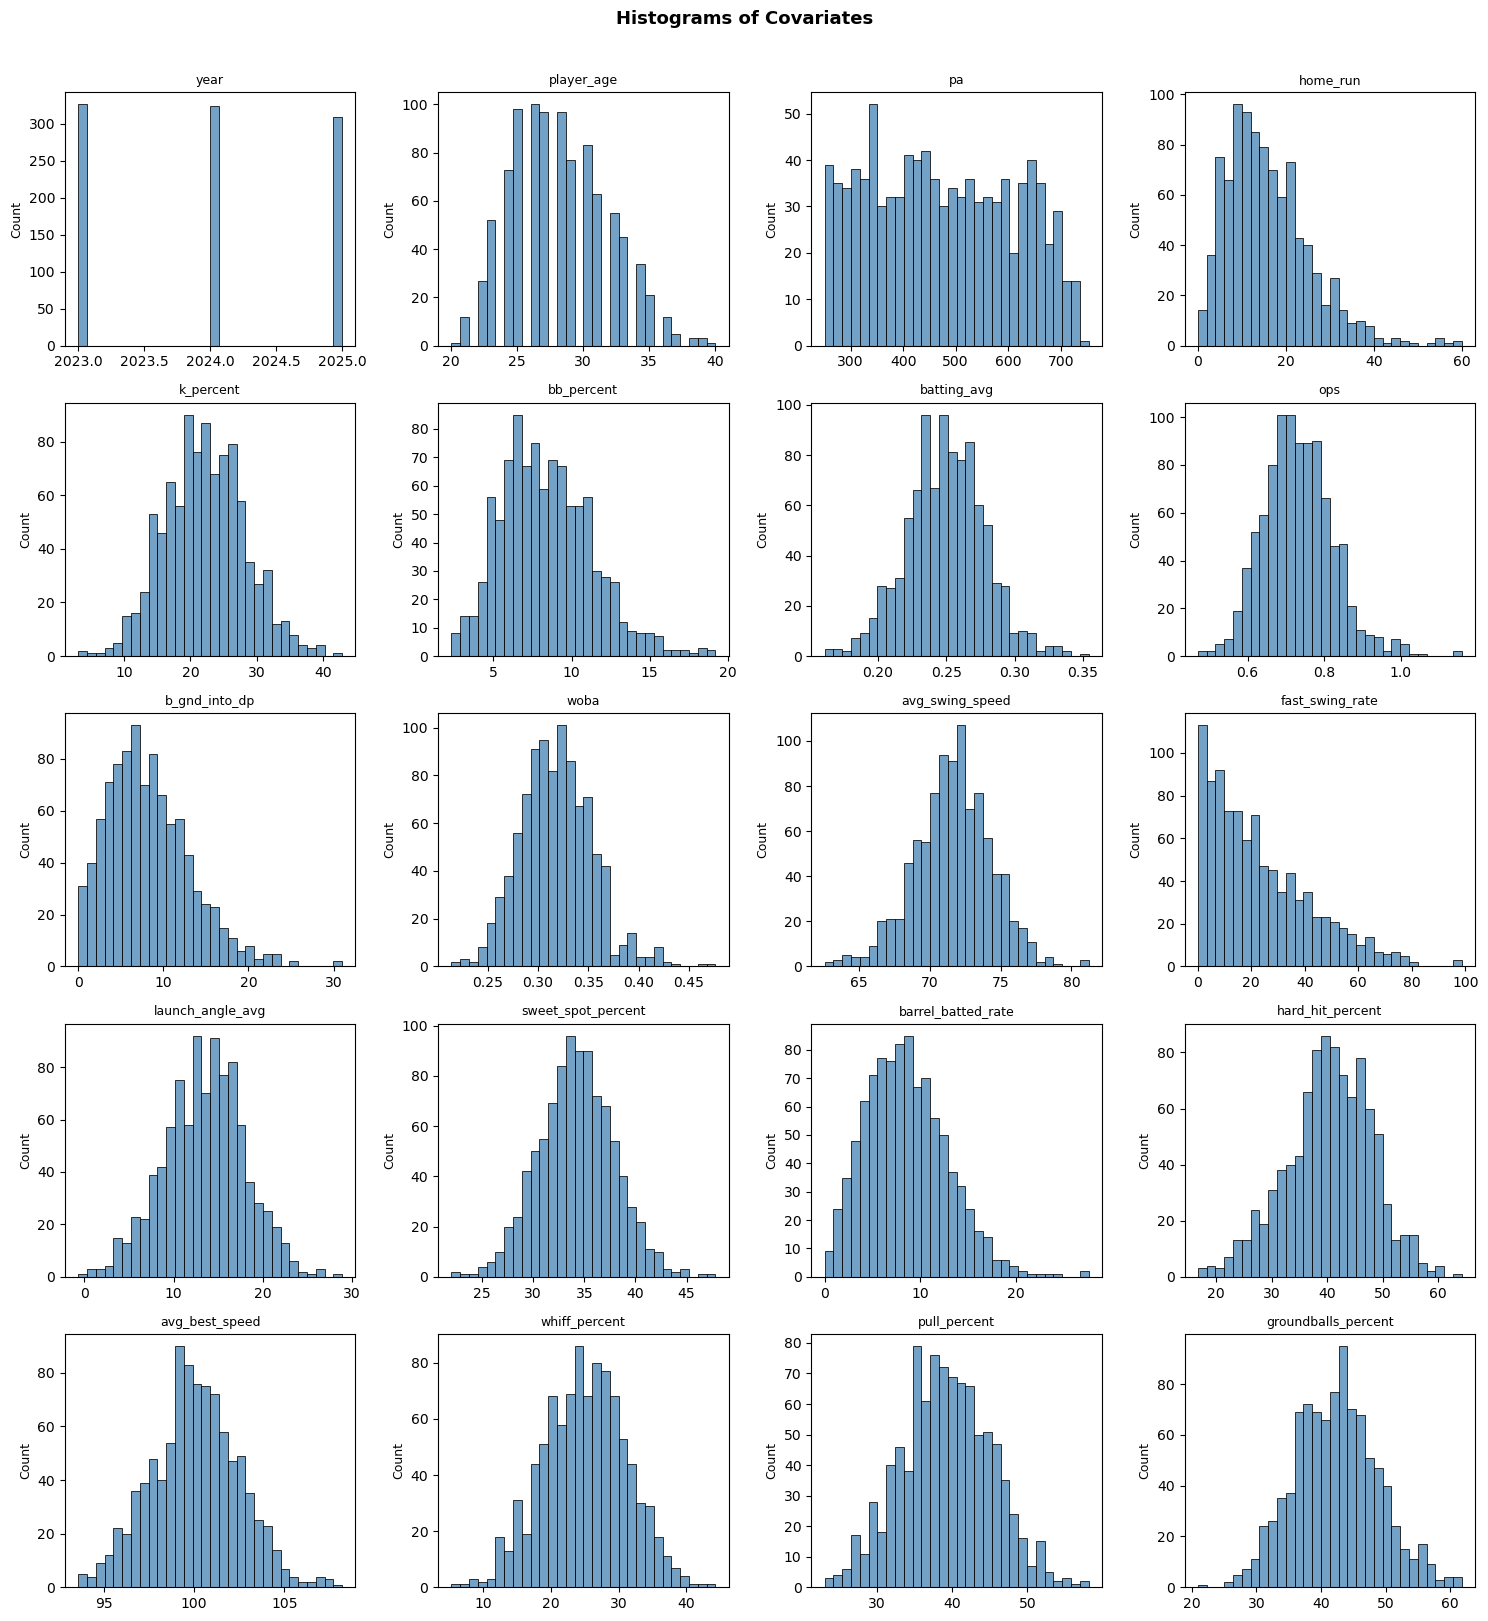

In [21]:
fig, axes = plt.subplots(5, 4, figsize = (15, 16))

axes = axes.flatten()

for i, col in enumerate(eda_vars):
    sns.histplot(
        data = df,
        x = col,
        bins = 30,
        ax = axes[i],
        color = "steelblue"
    )
    axes[i].set_title(col, fontsize = 9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count", fontsize = 9)

plt.suptitle("Histograms of Covariates", fontsize = 13, fontweight = "bold", y = 1.01)
plt.tight_layout()
plt.show()

Here I will make a few comments on the variables.

`year`: This variable is mostly uniform. I'm not too interested in using this variable as a predictor, more just looking to make sure there is a relatively even amount of samples from year to year.

`player_age`: This variable is slightly right skewed.

`pa`: Plate appearances appears to be mostly uniform besides the upper bound values.

`home_run`: The amount of home runs hit is heavily right skewed, as it is very hard to accumulate a lot of home runs.

`k_percent`, `batting_avg`, `launch_angle_avg`, `sweet_spot_percent`, `hard_hit_percent`, `avg_best_speed`, `whiff_percent`, `pull_percent`, `groundballs_percent`: appear to be roughly normal.

`bb_percent`, `barrel_batted_rate`: Appear to be decently right skewed.

`avg_swing_speed` appears to be symmetric but with a sharp peak.

`fast_swing_rate` appears to follow a logistic curve with lower values being way more frequent.

Additionally, we will create a summary table with some summary statistics as well as skew and kurtosis.

In [22]:
# Summary Table
summary_table = df[eda_vars].describe()[1:].T
summary_table['skew'] = df[eda_vars].skew()
summary_table['kurtosis'] = df[eda_vars].kurt()
summary_table = summary_table.round(2)

summary_table

,mean,std,min,25%,50%,75%,max,skew,kurtosis
year,2023.98,0.81,2023.00,2023.00,2024.00,2025.00,2025.00,0.03,-1.49
player_age,28.05,3.64,20.00,25.00,28.00,31.00,40.00,0.38,-0.34
pa,473.93,134.49,250.00,353.00,463.00,588.50,753.00,0.12,-1.16
home_run,15.53,9.53,0.00,9.00,14.00,21.00,60.00,1.11,1.88
k_percent,22.12,5.99,3.10,17.95,22.10,26.10,42.80,0.12,-0.02
bb_percent,8.39,2.88,2.30,6.30,8.10,10.30,19.20,0.57,0.36
batting_avg,0.25,0.03,0.16,0.23,0.25,0.27,0.35,0.04,0.34
ops,0.73,0.09,0.47,0.67,0.73,0.79,1.16,0.51,1.04
b_gnd_into_dp,8.51,4.73,0.00,5.00,8.00,11.00,31.00,0.81,0.99
woba,0.32,0.04,0.21,0.29,0.32,0.34,0.48,0.38,0.73


`home_run` has the highest absolute kurtosis at 1.88 which makes sense since its outliers values are on the higher end. It is also the most skewed.

#### Bivariate Analysis

We will start by making scatter plots of each variable against `ops`.

In [23]:
eda_vars

['year',
 'player_age',
 'pa',
 'home_run',
 'k_percent',
 'bb_percent',
 'batting_avg',
 'ops',
 'b_gnd_into_dp',
 'woba',
 'avg_swing_speed',
 'fast_swing_rate',
 'launch_angle_avg',
 'sweet_spot_percent',
 'barrel_batted_rate',
 'hard_hit_percent',
 'avg_best_speed',
 'whiff_percent',
 'pull_percent',
 'groundballs_percent']

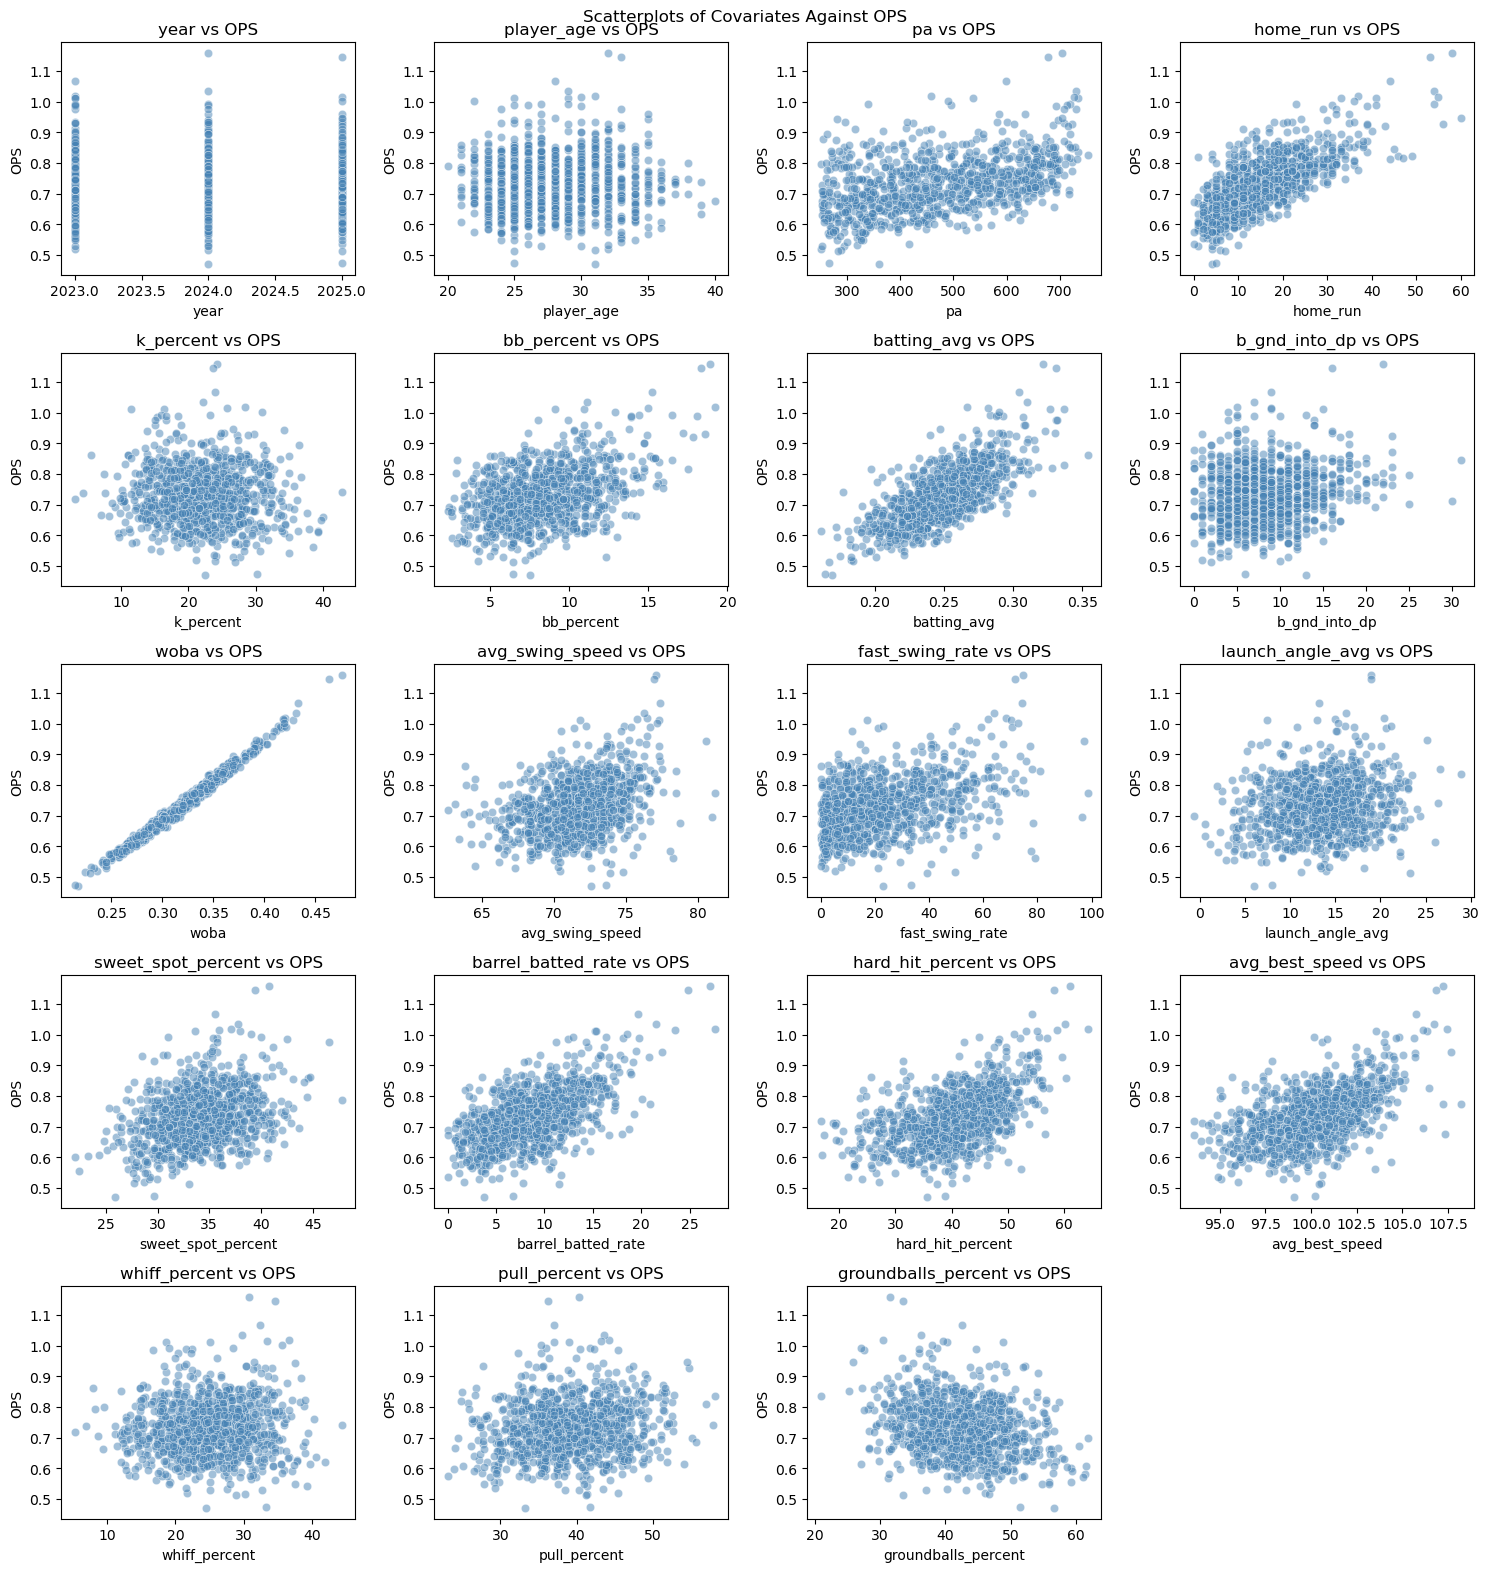

In [24]:
bivariate_vars = eda_vars.copy()
bivariate_vars.remove("ops")

fig, axes = plt.subplots(5, 4, figsize = (15, 16))
axes = axes.flatten()

for i, col in enumerate(bivariate_vars):
    sns.scatterplot(
        data = df,
        x = col,
        y = "ops",
        ax = axes[i],
        color = "steelblue",
        alpha = 0.5
    )

    axes[i].set_title(f"{col} vs OPS")
    axes[i].set_ylabel("OPS")

for j in range(len(bivariate_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Scatterplots of Covariates Against OPS")
plt.tight_layout()
plt.show()

Off the bat we see a very strong relationship between OPS and woba (weighted on-base average). This can be attributed to the fact that both wOBA and OPS are both some direct function of On Base Percentage. While they have their differences, it may not be suitable to include wOBA into our models since they are both partly derived from On Base Percentage.

For the other plots, there is a lot of noise in each, but some of the stats appear to have a mild linear relationship with OPS. We can further verify this with a correlation matrix

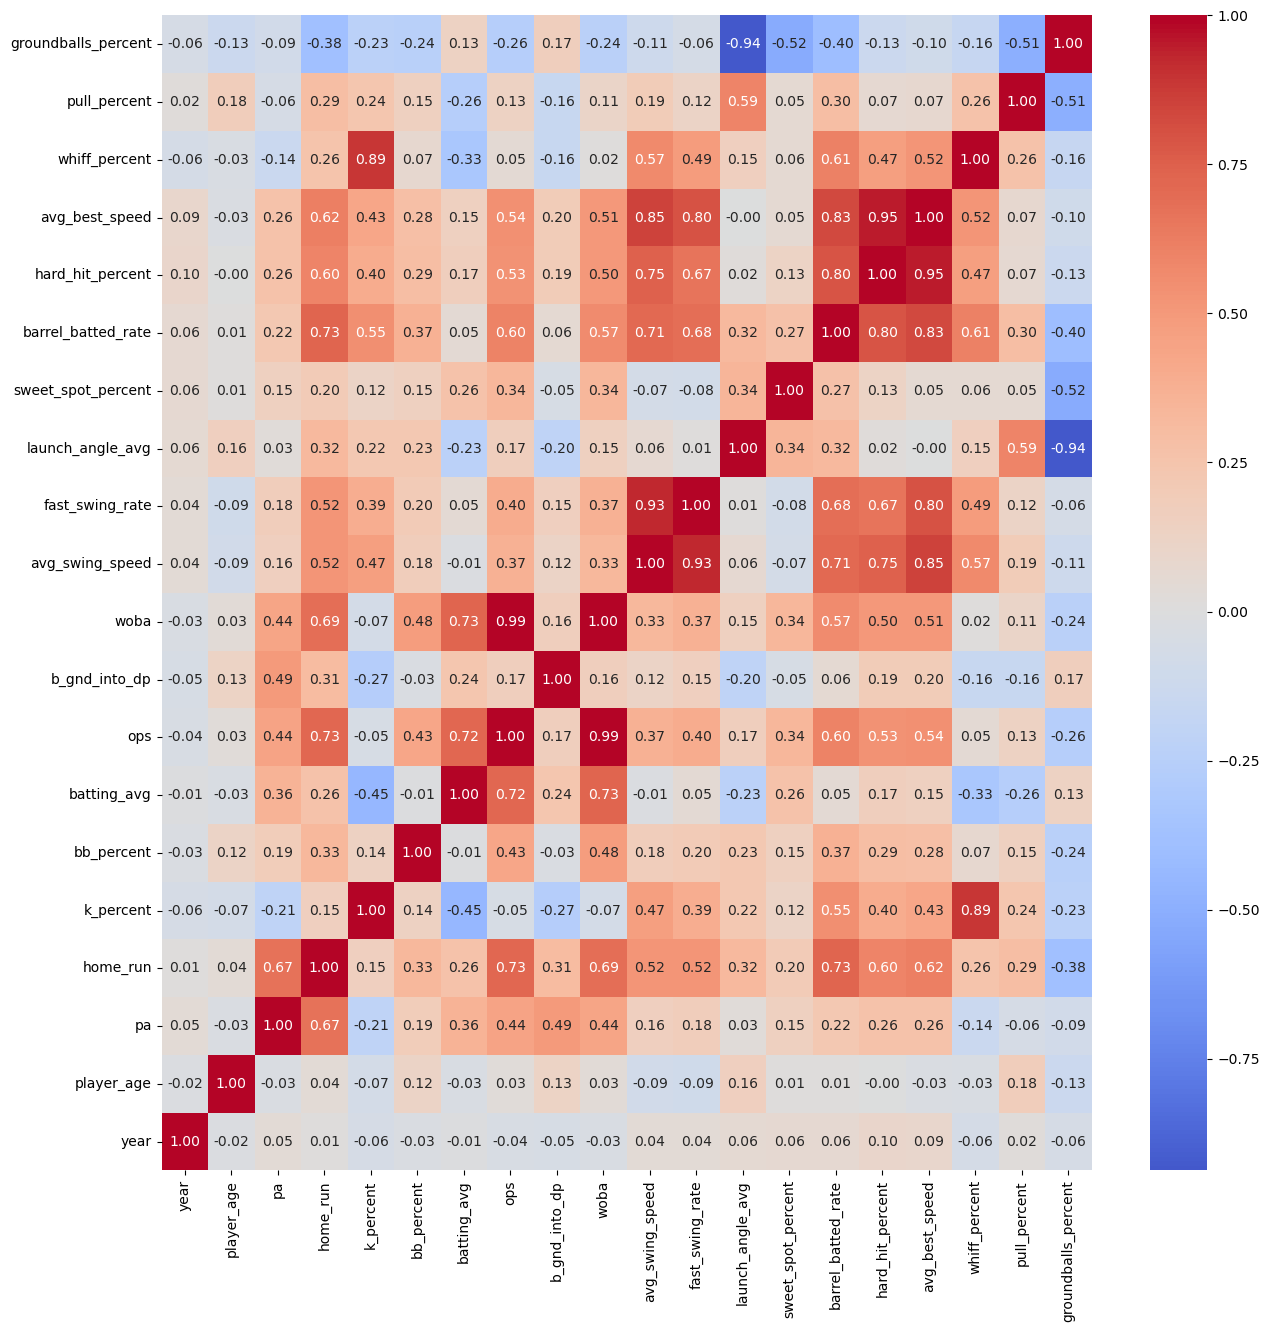

In [25]:
corr_matrix = df[eda_vars].corr()

# Reverse order of rows to match the columns
corr_matrix = corr_matrix.iloc[::-1]


plt.figure(figsize = (15, 15))

sns.heatmap(corr_matrix,
            annot = True,
            cmap = "coolwarm",
            fmt = ".2f",
            center = 0)

plt.show()

As shown in the correlation heatmap, `ops` has a very high correlation with `woba`. It is also decently correlated with `home_run`, `bb_percent`, `batting_avg`, `fast_swing_rate`, `barrel_batted_rate`, `hard_hit_percentage`, and `avg_best_speed`. A lot of the covariates are correlated with each other which is expected since some of them record the same or similar metrics.

Lastly, I want to see if there is an overall trend in OPS through time in years. We only have three years to choose from but small changes in between years are still significant. We will create a time series plot.

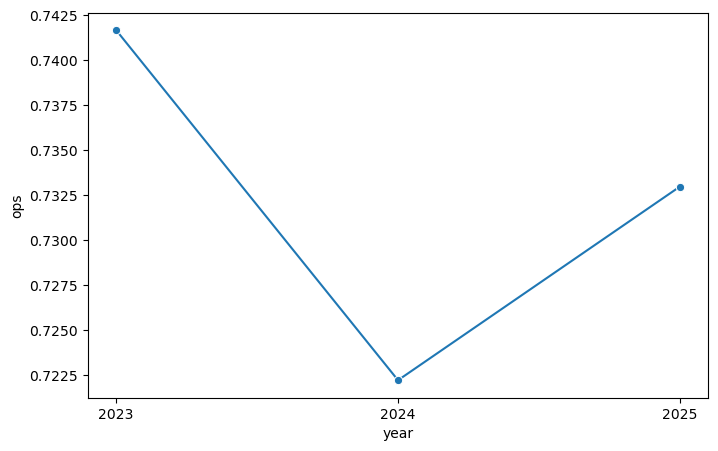

In [83]:
plt.figure(figsize = (8, 5))

ops_by_year = df.groupby("year")["ops"].mean().reset_index()

sns.lineplot(
    data = ops_by_year,
    x = "year",
    y = "ops",
    marker = "o"
)

plt.xticks([2023, 2024, 2025])

plt.show()

Based on this three year sample there doesn't appear to be a discernable trend in OPS. This is expected though because our data doesn't have a wide enough timespan.

# Results

# Conclusion

# References